In [2]:
all = [var for var in globals() if var[0] != "_"]
for var in all:
    del globals()[var]

del var, all
# This script clears all global variables except those starting with an underscore.

In [3]:
# Modeule imports
import numpy as np
import jax
import jax.numpy as jnp
import torch

import scipy.optimize as sci_opt
from scipy.optimize import NonlinearConstraint
import scipy.special
import module_opt_AD as my_opt

import matplotlib.pyplot as plt

import heat_equation_2D_for_students
import heat_equation_2D_for_students_jax

import importlib
importlib.reload(my_opt)
importlib.reload(heat_equation_2D_for_students)
importlib.reload(heat_equation_2D_for_students_jax)

from heat_equation_2D_for_students import HeatEquation2D
from heat_equation_2D_for_students_jax import HeatEquation2D_JAX

## Initial Solve Test

In [4]:
lx = .04  # length in x direction
ly = .04  # length in y direction
z = .04  # height of the domain
N = 25    # number of grid points in x, y direction
k_Si = 149  # thermal conductivity of silicon
rho_Si = 2323  # density of silicon
cp_Si = 704.611  # specific heat capacity of silicon
CFL = .1 # CFL number

def T0(x:np.ndarray, y:np.ndarray) -> np.ndarray:
    """
    Initial temperature distribution over the domain.
    """
    T_0 = np.zeros_like(x)
    ## Cosine Case
    T_0 = 70 * np.sin(x * np.pi / lx) * np.sin(y * np.pi / ly) + 293
    return T_0

heq_init = HeatEquation2D(x=lx, y=ly, height=z, n_x=N, n_y=N, k=k_Si, rho=rho_Si, cp=cp_Si, init_condition=T0)

In [5]:
def q_gen(x:np.ndarray, y:np.ndarray, a:np.float64, b:np.float64, c:np.float64) -> np.ndarray:
    """
    Heat generation function over the domain.
    """
    q = a*x + b*y + c
    return q

In [6]:
a0 = 1e5
b0 = 1e5
c0 = (1.5625*10**5 - 0.02*b0 - 0.02*a0)  # same formula as before

# a0 = 1.5625*10**5
# b0 = 1*10**6*0.0
# c0 = 1*10**6*0.0
heq_init.set_heat_generation(q_gen, a=a0, b=b0, c=c0)  # set heat generation function with design variables

In [7]:
v0 = 10.0
heq_init.set_fan_velocity(v=v0)  # set fan velocity

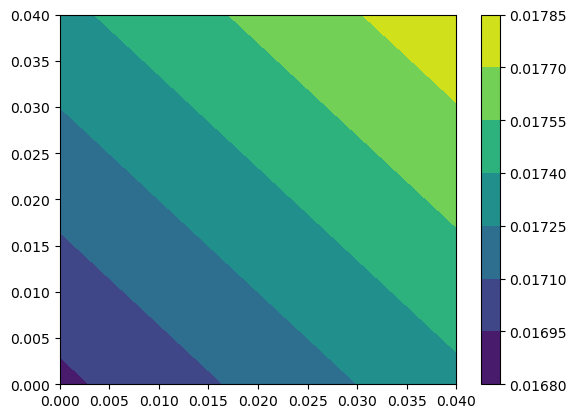

In [8]:
 ## plotting initial conditions
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, q_gen(heq_init.X, heq_init.Y, a0, b0, c0)*heq_init.dx*heq_init.dy*heq_init.height)
fig.colorbar(contour1,ax=ax)
plt.show()

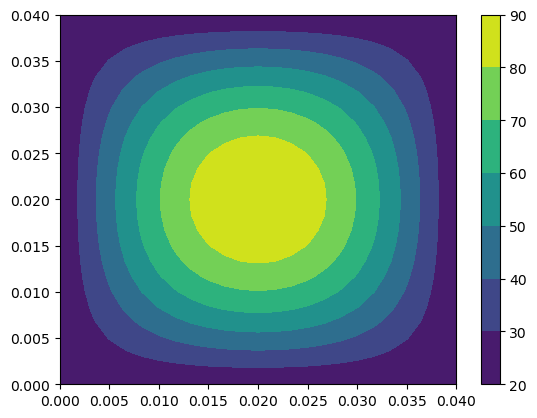

In [9]:
# plotting initial conditions T0
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, heq_init.u - 273)
fig.colorbar(contour1, ax=ax)
plt.show()

In [10]:
heq_init.solve_until_steady_state(tol=1e-3)

Iteration starts until steady state !
Steady State Reached in 50000 iterations with error 0.0011046114842656607 at time 152.57681666928303 seconds.


Text(0.5, 1.0, 'Temperature[℃] Distribution using Original Heat Equation Solver')

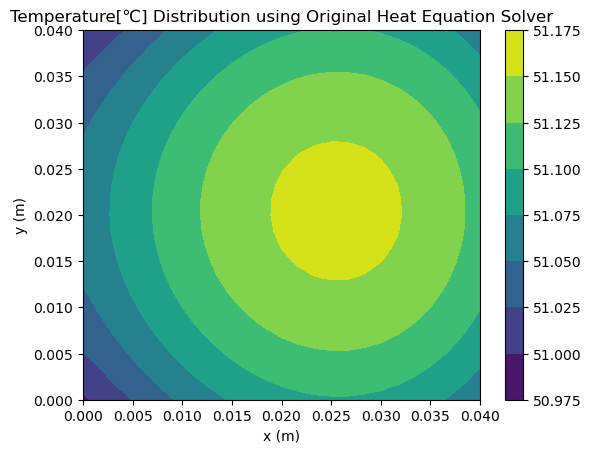

In [11]:
# plotting initial T distribution after solving
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, heq_init.u - 273)
fig.colorbar(contour1, ax=ax)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.title('Temperature[℃] Distribution using Original Heat Equation Solver')

## HeatEquation2D_Jax Solver

In [12]:
def T0_jax(x_mesh, y_mesh, lx, ly):
    """
    JAX 기반 초기 온도 분포 생성
    """
    # 70 * sin(x*pi/lx) * sin(y*pi/ly) + 293
    T_0 = 70 * jnp.sin(x_mesh * jnp.pi / lx) * jnp.sin(y_mesh * jnp.pi / ly) + 293.0
    return T_0

In [13]:
lx = .04  # length in x direction
ly = .04  # length in y direction
z = .04  # height of the domain
N = 25    # number of grid points in x, y direction
k_Si = 149  # thermal conductivity of silicon
rho_Si = 2323  # density of silicon
cp_Si = 704.611  # specific heat capacity of silicon
CFL = .1 # CFL number

heq_jax = HeatEquation2D_JAX(lx, ly, z, N, N, k=k_Si, rho=rho_Si, cp=cp_Si, CFL=CFL)
u0 = T0_jax(heq_jax.X, heq_jax.Y, .04, .04)

In [14]:
v0 = 10.0
a0 = 1e5
b0 = 1e5
c0 = (1.5625*10**5 - 0.02*b0 - 0.02*a0)  # same formula as before

x_jax = jnp.array([v0, a0, b0, c0])
u_jax = heq_jax.solve_steady_state(v0, (a0, b0, c0), u0, tol=1e-3, max_iter=50000)

Text(0.5, 1.0, 'Temperature[℃] Distribution using Jax-based Heat Equation Solver')

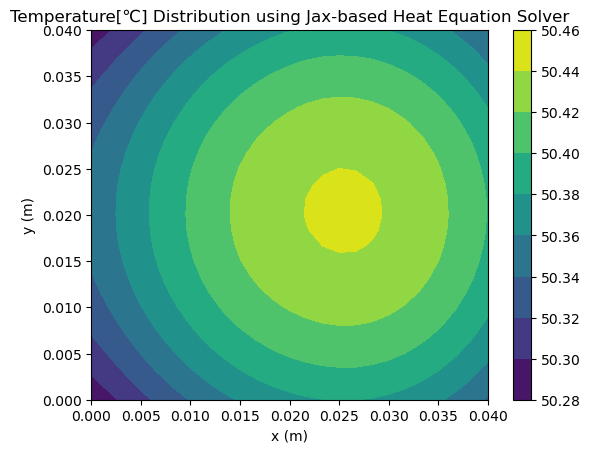

In [15]:
# plotting initial T distribution after solving
fig, ax = plt.subplots()
contour1 = ax.contourf(heq_init.X, heq_init.Y, u_jax - 273)
fig.colorbar(contour1, ax=ax)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.title('Temperature[℃] Distribution using Jax-based Heat Equation Solver')

In [20]:
np.max(np.abs(heq_init.u - u_jax))

np.float32(0.72042847)